# Heart Disease Prediction: Preprocessing and Modeling

This notebook prepares the Heart Disease dataset for machine-learning experiments and evaluates multiple classification algorithms using a consistent preprocessing and evaluation framework.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


In [4]:
df = pd.read_csv("../data/raw/heart.csv")

df.shape

(918, 12)

In [5]:
df["RestingBP"] = df["RestingBP"].replace(0, np.nan)
df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)

In [6]:
df[["RestingBP", "Cholesterol"]].isnull().sum()

RestingBP        1
Cholesterol    172
dtype: int64

In [7]:
X = df.drop(columns="HeartDisease")
y = df["HeartDisease"]

In [8]:
X.shape, y.shape

((918, 11), (918,))

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (734, 11)
Test set: (184, 11)


In [11]:
print("Full dataset:")
print(y.value_counts(normalize=True))

print("\nTraining set:")
print(y_train.value_counts(normalize=True))

print("\nTest set:")
print(y_test.value_counts(normalize=True))

Full dataset:
HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64

Training set:
HeartDisease
1    0.553134
0    0.446866
Name: proportion, dtype: float64

Test set:
HeartDisease
1    0.554348
0    0.445652
Name: proportion, dtype: float64


In [12]:
numerical_features = [
    "Age",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "Oldpeak"
]

categorical_features = [
    "Sex",
    "ChestPainType",
    "RestingECG",
    "ExerciseAngina",
    "ST_Slope"
]

In [13]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(
        strategy="median",
        add_indicator=True
    )),
    ("scaler", StandardScaler())
])

In [14]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

In [15]:
preprocessor = ColumnTransformer([
    (
        "num",
        numerical_pipeline,
        numerical_features
    ),
    (
        "cat",
        categorical_pipeline,
        categorical_features
    )
])

In [16]:
from sklearn.linear_model import LogisticRegression

In [17]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000
    ))
])

In [18]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [19]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [20]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [21]:
logistic_cv_results = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

In [22]:
for metric in scoring:
    scores = logistic_cv_results[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.3f} "
        f"(± {scores.std():.3f})"
    )

accuracy: 0.857 (± 0.039)
precision: 0.862 (± 0.048)
recall: 0.887 (± 0.025)
f1: 0.873 (± 0.032)
roc_auc: 0.928 (± 0.039)


### Logistic Regression — Cross-Validation Results

Logistic Regression was evaluated using stratified 5-fold cross-validation on the training data.

The model achieved a mean accuracy of 85.7%, precision of 86.2%, recall of 88.7%, F1-score of 87.3%, and ROC-AUC of 92.8%.

The relatively high recall indicates that the model successfully identifies a large proportion of patients with heart disease. The ROC-AUC score also suggests strong discrimination between the positive and negative classes.

These results establish Logistic Regression as a strong baseline for comparison with more complex machine-learning models.

In [23]:
from sklearn.ensemble import RandomForestClassifier

In [24]:
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

In [25]:
random_forest_cv_results = cross_validate(
    random_forest_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

In [26]:
for metric in scoring:
    scores = random_forest_cv_results[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.3f} "
        f"(± {scores.std():.3f})"
    )

accuracy: 0.856 (± 0.034)
precision: 0.857 (± 0.045)
recall: 0.892 (± 0.038)
f1: 0.873 (± 0.027)
roc_auc: 0.928 (± 0.027)


### Random Forest — Cross-Validation Results

Random Forest achieved a mean accuracy of 85.6%, precision of 85.7%, recall of 89.2%, F1-score of 87.3%, and ROC-AUC of 92.8%.

Its overall performance is very similar to Logistic Regression. Random Forest achieved slightly higher recall, while Logistic Regression achieved slightly higher accuracy and precision.

The identical ROC-AUC scores indicate that both models currently provide similarly strong discrimination between patients with and without heart disease.

These results suggest that increasing model complexity does not automatically lead to better predictive performance on this dataset.

In [27]:
from sklearn.svm import SVC

In [31]:
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(
        kernel="rbf",
        random_state=42
    ))
])

In [32]:
svm_cv_results = cross_validate(
    svm_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

In [33]:
for metric in scoring:
    scores = svm_cv_results[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.3f} "
        f"(± {scores.std():.3f})"
    )

accuracy: 0.854 (± 0.046)
precision: 0.850 (± 0.060)
recall: 0.902 (± 0.022)
f1: 0.874 (± 0.035)
roc_auc: 0.921 (± 0.036)


### Support Vector Machine — Cross-Validation Results

The Support Vector Machine achieved a mean accuracy of 85.4%, precision of 85.0%, recall of 90.2%, F1-score of 87.4%, and ROC-AUC of 92.1%.

Among the models evaluated so far, SVM achieved the highest recall, indicating strong sensitivity for detecting patients with heart disease. However, its ROC-AUC was slightly lower than those of Logistic Regression and Random Forest.

Overall, the three models demonstrate similar predictive performance, with different trade-offs between sensitivity and overall discrimination.

In [34]:
from sklearn.neighbors import KNeighborsClassifier

In [35]:
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(
        n_neighbors=5
    ))
])

In [36]:
knn_cv_results = cross_validate(
    knn_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

In [37]:
for metric in scoring:
    scores = knn_cv_results[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.3f} "
        f"(± {scores.std():.3f})"
    )

accuracy: 0.854 (± 0.034)
precision: 0.856 (± 0.037)
recall: 0.887 (± 0.021)
f1: 0.871 (± 0.029)
roc_auc: 0.903 (± 0.039)


### K-Nearest Neighbors — Cross-Validation Results

K-Nearest Neighbors achieved a mean accuracy of 85.4%, precision of 85.6%, recall of 88.7%, F1-score of 87.1%, and ROC-AUC of 90.3%.

The model demonstrated good overall classification performance, but its ROC-AUC was lower than those of Logistic Regression, Random Forest, and Support Vector Machine.

These results suggest that KNN is competitive in terms of accuracy and recall, but currently provides weaker overall class discrimination compared with the strongest models evaluated so far.

In [38]:
from sklearn.tree import DecisionTreeClassifier

In [39]:
decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

In [40]:
decision_tree_cv_results = cross_validate(
    decision_tree_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

In [41]:
for metric in scoring:
    scores = decision_tree_cv_results[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.3f} "
        f"(± {scores.std():.3f})"
    )

accuracy: 0.797 (± 0.058)
precision: 0.824 (± 0.054)
recall: 0.805 (± 0.075)
f1: 0.813 (± 0.057)
roc_auc: 0.796 (± 0.057)


### Decision Tree — Cross-Validation Results

The Decision Tree achieved a mean accuracy of 79.7%, precision of 82.4%, recall of 80.5%, F1-score of 81.3%, and ROC-AUC of 79.6%.

Its performance was substantially lower than that of Logistic Regression, Random Forest, SVM, and KNN. The model also showed relatively high variability across the cross-validation folds.

This suggests that a single Decision Tree may overfit the training data and generalize less effectively. The much stronger performance of Random Forest demonstrates the advantage of combining multiple decision trees rather than relying on a single tree.

In [45]:
from xgboost import XGBClassifier

In [46]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ))
])


In [47]:
xgb_cv_results = cross_validate(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)

In [48]:
for metric in scoring:
    scores = xgb_cv_results[f"test_{metric}"]

    print(
        f"{metric}: "
        f"{scores.mean():.3f} "
        f"(± {scores.std():.3f})"
    )

accuracy: 0.860 (± 0.024)
precision: 0.874 (± 0.032)
recall: 0.874 (± 0.025)
f1: 0.873 (± 0.020)
roc_auc: 0.930 (± 0.024)


### XGBoost — Cross-Validation Results

XGBoost achieved a mean accuracy of 86.0%, precision of 87.4%, recall of 87.4%, F1-score of 87.3%, and ROC-AUC of 93.0%.

Among the baseline models, XGBoost achieved the highest accuracy and ROC-AUC, indicating strong overall predictive performance and class discrimination.

However, SVM achieved a higher recall, showing that the choice of the best model depends on the evaluation criterion. In a healthcare context, recall is particularly important because false-negative predictions may have greater consequences.

Overall, XGBoost, Logistic Regression, Random Forest, and SVM emerged as the strongest baseline models.

In [49]:
model_results = {
    "Logistic Regression": logistic_cv_results,
    "Random Forest": random_forest_cv_results,
    "SVM": svm_cv_results,
    "KNN": knn_cv_results,
    "Decision Tree": decision_tree_cv_results,
    "XGBoost": xgb_cv_results
}

comparison_rows = []

for model_name, results in model_results.items():
    comparison_rows.append({
        "Model": model_name,
        "Accuracy": results["test_accuracy"].mean(),
        "Precision": results["test_precision"].mean(),
        "Recall": results["test_recall"].mean(),
        "F1": results["test_f1"].mean(),
        "ROC-AUC": results["test_roc_auc"].mean()
    })

comparison_df = pd.DataFrame(comparison_rows)

comparison_df.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.857,0.862,0.887,0.873,0.928
1,Random Forest,0.856,0.857,0.892,0.873,0.928
2,SVM,0.854,0.850,0.902,0.874,0.921
3,KNN,0.854,0.856,0.887,0.871,0.903
4,Decision Tree,0.797,0.824,0.805,0.813,0.796
5,XGBoost,0.860,0.874,0.874,0.873,0.930


In [50]:
comparison_df.sort_values(
    "ROC-AUC",
    ascending=False
).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
5,XGBoost,0.860,0.874,0.874,0.873,0.930
1,Random Forest,0.856,0.857,0.892,0.873,0.928
0,Logistic Regression,0.857,0.862,0.887,0.873,0.928
2,SVM,0.854,0.850,0.902,0.874,0.921
3,KNN,0.854,0.856,0.887,0.871,0.903
4,Decision Tree,0.797,0.824,0.805,0.813,0.796


In [51]:
from sklearn.model_selection import GridSearchCV

In [52]:
logistic_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__class_weight": [None, "balanced"]
}

In [53]:
logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

logistic_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=2000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [0.01, 0.1, ...], 'classifier__class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verb

In [54]:
print("Best parameters:")
print(logistic_grid.best_params_)

print("\nBest CV ROC-AUC:")
print(round(logistic_grid.best_score_, 3))

Best parameters:
{'classifier__C': 1, 'classifier__class_weight': None}

Best CV ROC-AUC:
0.928


### Logistic Regression — Hyperparameter Tuning

Logistic Regression was tuned using GridSearchCV with stratified 5-fold cross-validation and ROC-AUC as the optimization metric.

The search evaluated different regularization strengths (`C`) and class-weight configurations.

The best parameters were:

- C = 1
- class_weight = None

The best cross-validation ROC-AUC was 0.928, which is equal to the baseline Logistic Regression result.

Therefore, hyperparameter tuning did not improve the model, suggesting that the original Logistic Regression configuration was already well suited to this dataset.

In [55]:
random_forest_param_grid = {
    "classifier__n_estimators": [200, 400],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}

In [56]:
random_forest_grid = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=random_forest_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

random_forest_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 5, ...], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__min_samples_leaf': [1, 2, ...], 'classifier__min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and 

In [57]:
print("Best parameters:")
print(random_forest_grid.best_params_)

print("\nBest CV ROC-AUC:")
print(round(random_forest_grid.best_score_, 3))

Best parameters:
{'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 400}

Best CV ROC-AUC:
0.935


### Random Forest — Hyperparameter Tuning

Random Forest was tuned using GridSearchCV with stratified 5-fold cross-validation and ROC-AUC as the optimization metric.

The best configuration used 400 trees, a maximum tree depth of 10, square-root feature sampling, a minimum of 2 samples for splitting, and a minimum of 4 samples per leaf.

The best cross-validation ROC-AUC increased from 0.928 for the baseline model to 0.935 after tuning.

This represents a modest improvement and suggests that controlling tree complexity improved the model's generalization across the cross-validation folds.

In [58]:
svm_param_grid = [
    {
        "classifier__kernel": ["linear"],
        "classifier__C": [0.01, 0.1, 1, 10, 100],
        "classifier__class_weight": [None, "balanced"]
    },
    {
        "classifier__kernel": ["rbf"],
        "classifier__C": [0.1, 1, 10, 100],
        "classifier__gamma": ["scale", 0.01, 0.1, 1],
        "classifier__class_weight": [None, "balanced"]
    }
]

In [59]:
svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'classifier__C': [0.01, 0.1, ...], 'classifier__class_weight': [None, 'balanced'], 'classifier__kernel': ['linear']}, {'classifier__C': [0.1, 1, ...], 'classifier__class_weight': [None, 'balanced'], 'classifier__gamma': ['scale', 0.01, ...], 'classifier__kernel': ['rbf']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_r

In [60]:
print("Best parameters:")
print(svm_grid.best_params_)

print("\nBest CV ROC-AUC:")
print(round(svm_grid.best_score_, 3))

Best parameters:
{'classifier__C': 10, 'classifier__class_weight': None, 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf'}

Best CV ROC-AUC:
0.925


### Support Vector Machine — Hyperparameter Tuning

Support Vector Machine was tuned using GridSearchCV with stratified 5-fold cross-validation and ROC-AUC as the optimization metric.

The best configuration used an RBF kernel with C = 10, gamma = 0.01, and no class weighting.

The best cross-validation ROC-AUC increased from 0.921 for the baseline SVM to 0.925 after tuning.

The improvement was modest, indicating that the baseline SVM was already performing relatively well.

In [61]:
xgb_param_grid = {
    "classifier__n_estimators": [200, 400],
    "classifier__learning_rate": [0.01, 0.05, 0.1],
    "classifier__max_depth": [2, 3, 4],
    "classifier__subsample": [0.8, 1.0],
    "classifier__colsample_bytree": [0.8, 1.0]
}

In [62]:
xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__colsample_bytree': [0.8, 1.0], 'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [2, 3, ...], 'classifier__n_estimators': [200, 400], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and c

In [63]:
print("Best parameters:")
print(xgb_grid.best_params_)

print("\nBest CV ROC-AUC:")
print(round(xgb_grid.best_score_, 3))

Best parameters:
{'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 400, 'classifier__subsample': 0.8}

Best CV ROC-AUC:
0.936


### XGBoost — Hyperparameter Tuning

XGBoost was tuned using GridSearchCV with stratified 5-fold cross-validation and ROC-AUC as the optimization metric.

The best configuration used 400 estimators, a learning rate of 0.01, a maximum tree depth of 3, a subsample ratio of 0.8, and a column sampling ratio of 0.8.

The best cross-validation ROC-AUC increased from 0.930 for the baseline model to 0.936 after tuning.

This represents a modest improvement and produced the highest ROC-AUC among the tuned models. However, the result was nearly identical to the tuned Random Forest ROC-AUC of 0.935, indicating that the two ensemble methods perform similarly in terms of class discrimination.

In [64]:
best_logistic = logistic_grid.best_estimator_
best_random_forest = random_forest_grid.best_estimator_
best_svm = svm_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_

In [65]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [66]:
final_models = {
    "Logistic Regression": best_logistic,
    "Random Forest": best_random_forest,
    "SVM": best_svm,
    "XGBoost": best_xgb
}

In [67]:
test_results = []

for model_name, model in final_models.items():

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    test_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_score)
    })

test_results_df = pd.DataFrame(test_results)

test_results_df.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.891,0.887,0.922,0.904,0.932
1,Random Forest,0.902,0.889,0.941,0.914,0.931
2,SVM,0.880,0.870,0.922,0.895,0.944
3,XGBoost,0.902,0.896,0.931,0.913,0.933


In [68]:
test_results_df.sort_values(
    "ROC-AUC",
    ascending=False
).round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,SVM,0.880,0.870,0.922,0.895,0.944
3,XGBoost,0.902,0.896,0.931,0.913,0.933
0,Logistic Regression,0.891,0.887,0.922,0.904,0.932
1,Random Forest,0.902,0.889,0.941,0.914,0.931


## Final Test-Set Evaluation

The four strongest tuned models were evaluated on the previously unseen test set.

Random Forest and XGBoost achieved the highest accuracy at approximately 90.2%. Random Forest achieved the highest recall (94.1%), indicating that it detected the largest proportion of patients with heart disease.

SVM achieved the highest ROC-AUC (94.4%), demonstrating the strongest overall class discrimination on the test set, although its accuracy and F1-score were slightly lower than those of the ensemble models.

XGBoost achieved a balanced performance across all metrics, with 90.2% accuracy, 89.6% precision, 93.1% recall, 91.3% F1-score, and 93.3% ROC-AUC.

XGBoost had previously obtained the highest ROC-AUC during cross-validation and was therefore retained as the primary model selected during model development. The test-set results were not used for additional hyperparameter tuning.

Overall, the results indicate that several machine-learning approaches can achieve strong predictive performance on this dataset, with different models presenting different trade-offs between sensitivity and overall discrimination.

In [69]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

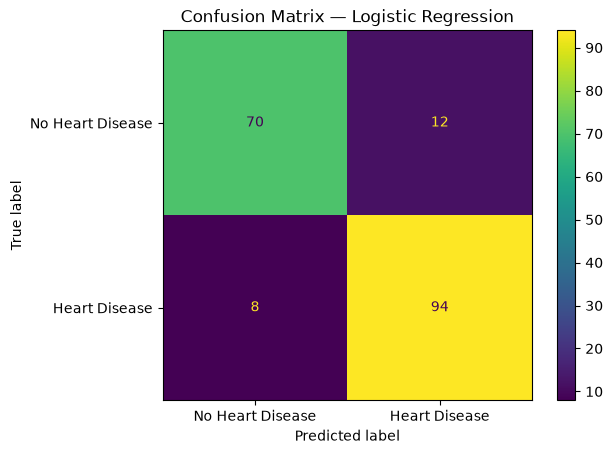

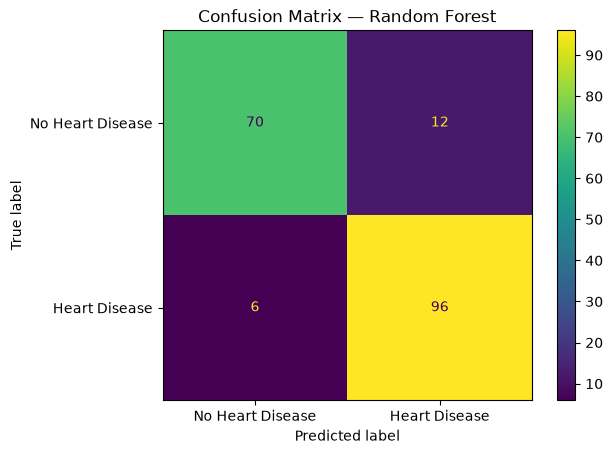

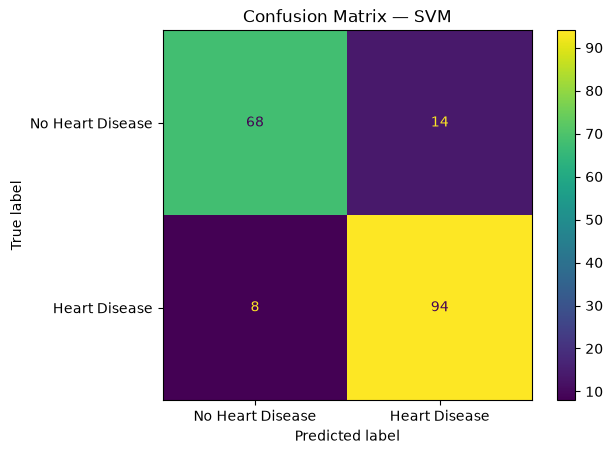

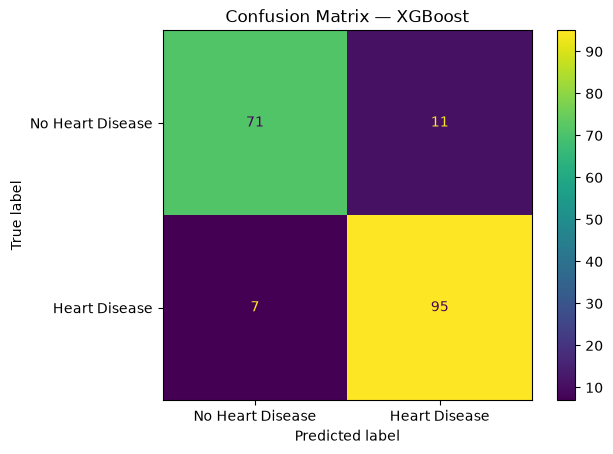

In [70]:
for model_name, model in final_models.items():
    y_pred = model.predict(X_test)

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["No Heart Disease", "Heart Disease"]
    )

    plt.title(f"Confusion Matrix — {model_name}")
    plt.show()

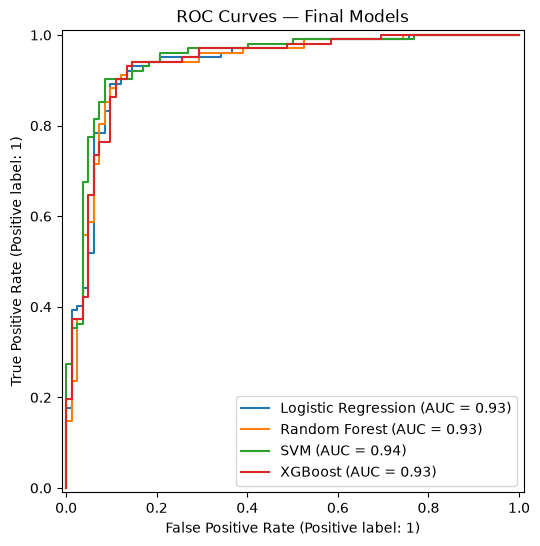

In [71]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))

for model_name, model in final_models.items():

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    RocCurveDisplay.from_predictions(
        y_test,
        y_score,
        name=model_name,
        ax=plt.gca()
    )

plt.title("ROC Curves — Final Models")
plt.show()

### ROC Curve Comparison

The ROC curves show that all four final models provide strong discrimination between patients with and without heart disease.

SVM achieved the highest test ROC-AUC of 0.944. XGBoost, Logistic Regression, and Random Forest also achieved strong and very similar ROC-AUC values of 0.933, 0.932, and 0.931 respectively.

Although SVM obtained the highest ROC-AUC on the test set, XGBoost remained the primary model because it had been selected based on cross-validation performance before the test set was evaluated.